# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           60          |
|------------|----------------------|
| A. Tudor Berechet  |        6137946       |
| B. Luca-Adam Bledea-Floruta  |        6205682       |
| C. Alejandro Huguet Lorente  |        6145744       |
| D. Adam Pobudejski  |        6155332       |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [2]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        actions = agent.get_valid_actions(maze=maze)
        return random.choice(actions)

    def e_greedy(self, agent: Agent,  maze: Maze, eps: float):
            """
            The e-greedy exploration strategy selects a random action with probability eps,
            and the action with highest q-value with probability 1 - eps. A value of epsilon
            close to 0 favours exploitation, while a value close to 1 favours exploration.
            """
            state = agent.get_state(maze=maze)
            actions = agent.get_valid_actions(maze=maze)

            p = np.random.random()
            if p < eps:                             # exploration
                action = random.choice(actions)
            else:                                   # exploitation
                q_values = np.array([self.q_table.get_q(state=state, action=action) for action in actions])
                
                # Find all actions that share the maximum Q-value and pick randomly among them
                max_q = np.max(q_values)
                best_actions = [actions[i] for i in range(len(actions)) if q_values[i] == max_q]
                action = random.choice(best_actions)
            
            return action


    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        state = agent.get_state(maze=maze)
        actions = agent.get_valid_actions(maze=maze)
        
        # assign probability based on the formula 
        q_values = np.array([self.q_table.get_q(state=state, action=action) for action in actions])
    
        denominator = np.sum(np.exp(q_values / temperature))
        p_a = (np.exp(q_values / temperature) / denominator)

        return np.random.choice(actions, p=p_a)


We implemented the three exploration strategies required:
1. Random exploration  
- The agent samples uniformly from the valid actions in the current state:
$
a \sim \text{Uniform}(\mathcal{A}_{\text{valid}}(s))
$

2. $\epsilon$-greedy exploration  
- With probability $\epsilon$, the agent explores randomly, and with probability $1-\epsilon$, it exploits the current best action:
$$
a =
\begin{cases}
\text{random action in } \mathcal{A}_{\text{valid}}(s), & \text{with probability } \epsilon \\
\arg\max\limits_{a' \in \mathcal{A}_{\text{valid}}(s)} Q(s,a'), & \text{with probability } 1-\epsilon
\end{cases}
$$
- To avoid bias when several actions have the same maximal Q-value, ties are broken randomly among the best actions.

3. Boltzmann (softmax) exploration  
- The agent assigns probabilities to valid actions according to their Q-values:
$$
P(a \mid s)=\frac{\exp\left(Q(s,a)/T\right)}{\sum\limits_{a' \in \mathcal{A}_{\text{valid}}(s)} \exp\left(Q(s,a')/T\right)}
$$
- where $T$ is the temperature parameter:
    - **Higher $T$** increases exploration  
    - **Lower $T$** makes the policy more greedy.

Overall, these strategies provide complementary exploration-exploitation behavior: 
- purely stochastic (random) 
- mixed stochastic/greedy ($\epsilon$-greedy) 
- value-weighted probabilistic (Boltzmann)

#### Question 2

We chose the initial hyperparameter values as moderate defaults. 
- For ε-greedy, ε = 0.1 means the agent explores occasionally but still exploits the best-known action most of the time
- For Boltzmann, T = 1.0 gives a balanced softmax distribution that is sensitive to Q-value differences without becoming almost uniform or almost deterministic. 

These starting values provide a reasonable exploration-exploitation tradeoff before any tuning.

In [3]:
# Create a Maze instance.
maze_default = Maze("./../data/easy_maze.txt")
maze_default.set_reward(x=9, y=9, reward=10)
maze_default.set_terminal(x=9, y=9)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze_default.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)
# Create a learner.
params = {"alpha": 0.7, "gamma": 0.9}
# learner = QLearning(q_table, params)

# Hyper-parameters.
def agent_cycle(n_episodes=300, strategy=0, eps=0.1, temperature=1.0, maze=maze_default):
    """
    Runs the agent through multiple episodes in the maze using a specified exploration strategy.

    Args:
        n_episodes (int, optional): Number of episodes to run. Defaults to 300.
        strategy (int, optional): Exploration strategy to use (0: random, 1: e-greedy, 2: Boltzmann). Defaults to 0.
        eps (float, optional): Epsilon value for e-greedy strategy. Defaults to 0.1.
        temperature (float, optional): Temperature parameter for Boltzmann strategy. Defaults to 1.0.
        learner (optional): Learning algorithm to update the Q-table (not yet implemented). Defaults to None.

    Returns:
        - episode_lengths: List of episode lengths (number of steps per episode).
        - episode_rewards: List of total rewards obtained in each episode.
    """
    episode_lengths = []
    episode_rewards = []

    for episode in tqdm(range(n_episodes)):
        agent.reset()
        total_reward = 0
        total_length = 0

        while not agent.get_state(maze=maze).done:
            # 1. Get current state
            current_state = agent.get_state(maze=maze)
            
            # 2. Select an action (random, e_greedy, or boltzmann)
            if strategy == 0:
                action = exploration_strategy.random(agent, maze)
            elif strategy == 1:
                action = exploration_strategy.e_greedy(agent, maze, eps=eps)
            elif strategy == 2:
                action = exploration_strategy.boltzmann(agent, maze, temperature)

            # 3. Execute the action and move the agent
            next_state, reward, done = agent.step(action, maze)

            # 4. Call the learner  (not yet implemented)

            # 5. Update the total_reward/length
            total_reward += reward
            total_length += 1
        

        episode_rewards.append(total_reward)
        episode_lengths.append(total_length)

    return episode_lengths, episode_rewards


We implemented an episode loop that runs the agent for multiple episodes and tracks both episode length and total reward. For each episode we:

1. Reset the agent to the start state.
2. Repeat until terminal state:
   - Read current state.
   - Choose an action using the selected exploration strategy.
   - Execute the action to obtain next state, reward, and done flag.
   - Update episode metrics (total reward and number of steps).
3. Store episode metrics.

The function returns:
- Episode lengths: number of steps needed to finish each episode.
- Episode rewards: cumulative reward per episode.

At this stage, no learning rule is applied yet (no Q-value update), so this cycle is a baseline interaction and measurement pipeline.

No additional steps are needed. The decision loop is fully captured by reading state, selecting an action, and executing it, there is no hidden state to track or separate reward accumulation.

#### Question 3

In [4]:
def agent_cycle_early_stop(n_episodes=300, strategy=0, eps=0.1, temperature=1.0, steps_criterion=30000):
    """
    Runs the agent through multiple episodes in the maze using a specified exploration strategy,
    with early stopping if the total number of steps exceeds a given criterion.

    Args:
        n_episodes (int, optional): Number of episodes to run. Defaults to 300.
        strategy (int, optional): Exploration strategy to use (0: random, 1: e-greedy, 2: Boltzmann). Defaults to 0.
        eps (float, optional): Epsilon value for e-greedy strategy. Defaults to 0.1.
        temperature (float, optional): Temperature parameter for Boltzmann strategy. Defaults to 1.0.
        steps_criterion (int, optional): Maximum total steps before early stopping. Defaults to 30000.

    Returns:
        - episode_lengths: List of episode lengths (number of steps per episode).
        - episode_rewards: List of total rewards obtained in each episode.
    """
    episode_lengths = []
    episode_rewards = []

    total_steps = 0 

    for episode in tqdm(range(n_episodes)):
        agent.reset()
        total_reward = 0
        total_length = 0

        while not agent.get_state(maze=maze_default).done:
            # 1. Get current state
            current_state = agent.get_state(maze=maze_default)
            
            # 2. Select an action (random, e_greedy, or boltzmann)
            if strategy == 0:
                action = exploration_strategy.random(agent, maze_default)
            elif strategy == 1:
                action = exploration_strategy.e_greedy(agent, maze_default, eps=eps)
            elif strategy == 2:
                action = exploration_strategy.boltzmann(agent, maze_default, temperature)

            # 3. Execute the action and move the agent
            next_state, reward, done = agent.step(action, maze_default)
            total_steps += 1

            # 4. Call the learner (not yet implemented)
            # learner.learn(current_state, action, r, next_state)

            # 5. Update the total_reward/length
            total_reward += reward
            total_length += 1

            if total_steps >= steps_criterion:
                episode_rewards.append(total_reward)
                episode_lengths.append(total_length)
                return episode_lengths, episode_rewards

        episode_rewards.append(total_reward)
        episode_lengths.append(total_length)

    return episode_lengths, episode_rewards


# Q3 verification: strict stop at exactly 30000 total steps
episode_lengths_q3, episode_rewards_q3 = agent_cycle_early_stop(
    n_episodes=10000,   # intentionally large so stopping is controlled by steps_criterion
    strategy=0,
    steps_criterion=30000
)

total_steps_q3 = sum(episode_lengths_q3)
print("Episodes executed:", len(episode_lengths_q3))
print("Total steps:", total_steps_q3)

assert total_steps_q3 == 30000, f"Expected 30000, got {total_steps_q3}"
print("Q3 verification passed: stopped exactly at 30000 steps.")

  0%|          | 9/10000 [00:00<00:32, 304.03it/s]

Episodes executed: 10
Total steps: 30000
Q3 verification passed: stopped exactly at 30000 steps.


We implement stopping using a hard global step budget per run. The variable total_steps is incremented after each environment step, and the run returns immediately when total_steps >= steps_criterion. With steps_criterion = 30000, verification shows sum(episode_lengths) = 30000, confirming that no additional step is executed beyond the cap.

### Unit Tests for Questions 1, 2 and 3

In [5]:
# Unit tests for Questions 1, 2, and 3

def make_fresh_env():
    test_maze = Maze("./../data/easy_maze.txt")
    test_maze.set_reward(x=9, y=9, reward=10)
    test_maze.set_terminal(x=9, y=9)

    test_agent = Agent(start_x=0, start_y=0)
    test_states = test_maze.get_all_states()
    test_actions = [Action(id) for id in ["up", "down", "left", "right"]]
    test_q_table = QTable(test_states, test_actions)
    test_strategy = ExplorationStrategy(test_q_table)

    return test_maze, test_agent, test_q_table, test_strategy, test_actions


old_maze = globals().get("maze", None)
old_agent = globals().get("agent", None)
old_q_table = globals().get("q_table", None)
old_exploration_strategy = globals().get("exploration_strategy", None)

try:
    maze, agent, q_table, exploration_strategy, test_actions = make_fresh_env()

    # Q1: random() must always return a valid action
    valid_actions = agent.get_valid_actions(maze=maze)
    for _ in range(20):
        action = exploration_strategy.random(agent, maze)
        assert action in valid_actions

    # Q1: e_greedy() with eps=0 should pick the unique best action
    state = agent.get_state(maze=maze)
    q_table.set_q(state, test_actions[0], -1.0)
    q_table.set_q(state, test_actions[1], 5.0)
    q_table.set_q(state, test_actions[2], 0.0)
    q_table.set_q(state, test_actions[3], 1.0)

    greedy_action = exploration_strategy.e_greedy(agent, maze, eps=0.0)
    assert greedy_action == test_actions[1]

    # Q1: e_greedy() with eps=1 should still return a valid action
    for _ in range(20):
        action = exploration_strategy.e_greedy(agent, maze, eps=1.0)
        assert action in valid_actions

    # Q1: boltzmann() should always return a valid action
    for _ in range(20):
        action = exploration_strategy.boltzmann(agent, maze, temperature=1.0)
        assert action in valid_actions

    # Q2: agent_cycle() should return one length and reward per episode
    q_snapshot = {action.id: q_table.get_q(state, action) for action in test_actions}
    lengths, rewards = agent_cycle(n_episodes=3, strategy=0, maze=maze)

    assert len(lengths) == 3
    assert len(rewards) == 3
    assert all(length > 0 for length in lengths)
    assert all(isinstance(reward, (int, float, np.integer, np.floating)) for reward in rewards)

    # Q2: no learner means the Q-table should not change
    for action in test_actions:
        assert q_table.get_q(state, action) == q_snapshot[action.id]

    # Q3: strict stopping should return exactly at the specified global step budget
    lengths_es, rewards_es = agent_cycle_early_stop(
        n_episodes=10000,
        strategy=0,
        steps_criterion=30000
    )
    assert sum(lengths_es) == 30000

    print("All Q1, Q2, and Q3 tests passed.")

finally:
    if old_maze is not None:
        maze = old_maze
    if old_agent is not None:
        agent = old_agent
    if old_q_table is not None:
        q_table = old_q_table
    if old_exploration_strategy is not None:
        exploration_strategy = old_exploration_strategy

  0%|          | 4/10000 [00:00<01:10, 141.76it/s]

All Q1, Q2, and Q3 tests passed.


#### Question 4

### Toy maze

In [6]:
maze_toy = Maze("./../data/toy_maze.txt")
maze_toy.set_reward(x=9, y=9, reward=10)
maze_toy.set_terminal(x=9, y=9)

In [7]:
single_run_lengths, _ = agent_cycle(
    n_episodes=50,
    strategy=0,
    maze=maze_toy
)

print("Step counts per episode for one run:")
print(single_run_lengths)

100%|██████████| 50/50 [00:00<00:00, 898.02it/s]

Step counts per episode for one run:
[1710, 1550, 966, 440, 1106, 4192, 1200, 302, 1274, 4630, 1714, 360, 1344, 534, 616, 2872, 1176, 730, 1402, 2400, 1084, 126, 1216, 1022, 554, 4146, 2530, 1896, 436, 490, 746, 864, 416, 606, 832, 954, 1816, 576, 1286, 994, 370, 1324, 1222, 518, 3200, 1042, 622, 618, 310, 540]


Run number 1


100%|██████████| 300/300 [00:00<00:00, 890.50it/s]


Run number 2


100%|██████████| 300/300 [00:00<00:00, 846.35it/s]


Run number 3


...

100%|██████████| 300/300 [00:00<00:00, 851.39it/s]


Run number 9


100%|██████████| 300/300 [00:00<00:00, 927.65it/s]


Run number 10


100%|██████████| 300/300 [00:00<00:00, 916.51it/s] 


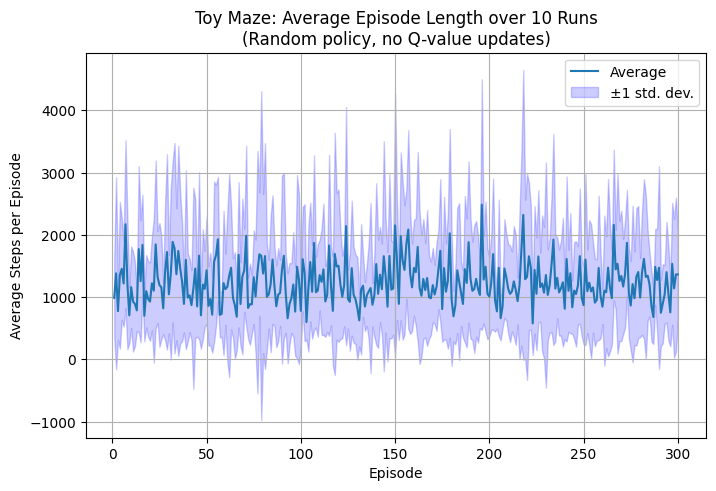

In [8]:
all_lengths = []
for run in range(10):
    print("Run number " + str(run + 1))
    episode_lengths, episode_rewards = agent_cycle(maze=maze_toy)
    all_lengths.append(episode_lengths)

min_episodes = min(len(length) for length in all_lengths)

# Compute averages and standard deviations on the common episode window
avg_lengths = []
std_lengths = []
for ep in range(min_episodes):
    episode_steps = [length[ep] for length in all_lengths]
    avg_lengths.append(np.mean(episode_steps))
    std_lengths.append(np.std(episode_steps))

avg_lengths = np.array(avg_lengths)
std_lengths = np.array(std_lengths)

plt.figure(figsize=(8, 5))
plt.plot(range(1, min_episodes + 1), avg_lengths, label='Average')
plt.fill_between(
    range(1, min_episodes + 1),
    avg_lengths - std_lengths,
    avg_lengths + std_lengths,
    color='b',
    alpha=0.2,
    label='±1 std. dev.'
)
plt.xlabel('Episode')
plt.ylabel('Average Steps per Episode')
plt.title('Toy Maze: Average Episode Length over 10 Runs\n(Random policy, no Q-value updates)')
plt.grid(True)
plt.legend()
plt.show()

In the toy maze, the average number of steps per episode does not show a consistent downward trend, so there is no evidence of learning. The ±1 standard deviation band indicates substantial variability across runs for the same episode index. To keep the comparison meaningful when runs have different lengths, we compute averages only up to the minimum number of episodes shared by all 10 runs.

### Easy maze

In [9]:
maze_easy = Maze("./../data/easy_maze.txt")
maze_easy.set_reward(x=9, y=9, reward=10)
maze_easy.set_terminal(x=9, y=9)

In [10]:
single_run_lengths, _ = agent_cycle(
    n_episodes=50,
    strategy=0,
    maze=maze_easy
)

print("Step counts per episode for one run:")
print(single_run_lengths)

100%|██████████| 50/50 [00:00<00:00, 305.62it/s]

Step counts per episode for one run:
[17600, 604, 298, 690, 2358, 1120, 310, 1536, 12490, 920, 148, 4700, 594, 7600, 778, 360, 612, 1142, 760, 2502, 190, 3626, 386, 10734, 3556, 2062, 1624, 192, 612, 4108, 6022, 1058, 496, 372, 182, 15268, 208, 570, 632, 6908, 1188, 3162, 344, 13748, 2782, 17344, 2100, 116, 4502, 11704]


Run number 1


100%|██████████| 300/300 [00:00<00:00, 317.30it/s]


Run number 2


100%|██████████| 300/300 [00:00<00:00, 343.36it/s]


Run number 3


...

100%|██████████| 300/300 [00:00<00:00, 340.10it/s]


Run number 9


100%|██████████| 300/300 [00:00<00:00, 354.80it/s]


Run number 10


100%|██████████| 300/300 [00:00<00:00, 317.04it/s]


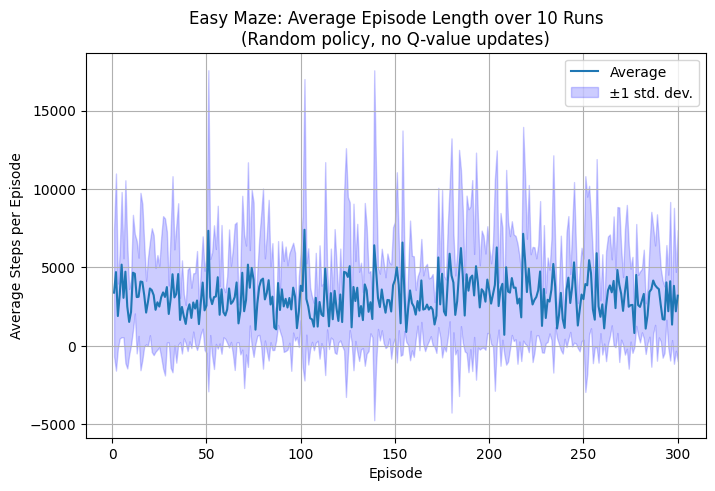

In [11]:
all_lengths = []
for run in range(10):
    print("Run number " + str(run + 1))
    episode_lengths, episode_rewards = agent_cycle(maze=maze_easy)
    all_lengths.append(episode_lengths)

min_episodes = min(len(length) for length in all_lengths)

# Compute averages and standard deviations on the common episode window
avg_lengths = []
std_lengths = []
for ep in range(min_episodes):
    episode_steps = [length[ep] for length in all_lengths]
    avg_lengths.append(np.mean(episode_steps))
    std_lengths.append(np.std(episode_steps))

avg_lengths = np.array(avg_lengths)
std_lengths = np.array(std_lengths)

plt.figure(figsize=(8, 5))
plt.plot(range(1, min_episodes + 1), avg_lengths, label='Average')
plt.fill_between(
    range(1, min_episodes + 1),
    avg_lengths - std_lengths,
    avg_lengths + std_lengths,
    color='b',
    alpha=0.2,
    label='±1 std. dev.'
)
plt.xlabel('Episode')
plt.ylabel('Average Steps per Episode')
plt.title('Easy Maze: Average Episode Length over 10 Runs\n(Random policy, no Q-value updates)')
plt.grid(True)
plt.legend()
plt.show()

In the easy maze, we observe the same pattern: the average steps per episode fluctuate but do not steadily decrease, so the agent does not learn here either. The ±1 standard deviation region is larger than in the toy maze, reflecting higher uncertainty in the larger state space. As above, we average only over the minimum common episode count across the 10 runs to ensure a fair episode-by-episode comparison.


The explanation to draw from the conclusion is that the agent cannot improve because no Q-value updates are performed. All actions are valued at 0, so the selection probabilities never change and there is no mechanism in place yet making the agent prefer shorter than longer paths.

#### Question 5

In [12]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, next_possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        
        alpha = self.params['alpha']
        gamma = self.params['gamma']
        
        q_old = self.q_table.get_q(state, action)
        
        if done:
            q_max_next = 0.0
        else:
            # "optimistic" approach - compute the best possible q-value for the next state, even if the agent didn't choose it
            q_max_next = max([self.q_table.get_q(next_state, a) for a in next_possible_actions])
            
        q_new = q_old + alpha * (reward + gamma * q_max_next - q_old)
        self.q_table.set_q(state, action, q_new)


In [13]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        alpha = self.params['alpha']
        gamma = self.params['gamma']
        
        q_old = self.q_table.get_q(state, action)
        
        if done:
            q_next = 0.0
        else:
            # compute the q-value for the next state based on the policy the agent actually follows
            q_next = self.q_table.get_q(next_state, next_action)
            
        q_new = q_old + alpha * (reward + gamma * q_next - q_old)
        self.q_table.set_q(state, action, q_new)


## Q-Learning and SARSA

Both algorithms are tabular reinforcement learning algorithms that update Q-values using the same Bellman equation — they only differ in how they estimate the value of the next state.

**Q-Learning** is off-policy: it always uses the maximum Q-value of the next state, assuming the agent will act optimally from there. This makes it aggressive and works well in deterministic environments, but it can overestimate values when there's randomness.

**SARSA** is on-policy: it uses the Q-value of the action the agent actually takes next, according to its current policy. This makes it more conservative and realistic, especially when the agent is still exploring.

The classic illustration is cliff-walking: Q-Learning learns the shortest path along the cliff edge, while SARSA learns a safer detour — because it accounts for the occasional misstep its policy will make.

#### Question 6

In [14]:
#Every run needs a fresh environment - new maze, new agent, new q-table, etc

def make_environment(maze_path):
    maze = Maze(maze_path)
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)
    agent = Agent(start_x=0, start_y=0)
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)
    return maze, agent, q_table, exploration_strategy


# Cycle with Q-Learning and early stopping 
def agent_cycle_qlearn(n_episodes=300, strategy=1, eps=0.1, temperature=1.0, learner=None, steps_criterion=30000):
    episode_lengths = []
    episode_rewards = []
    total_steps = 0 

    for episode in tqdm(range(n_episodes), desc="Q-Learning", leave=False):
        agent.reset()
        total_reward = 0
        total_length = 0
        current_state = agent.get_state(maze=maze)

        while not current_state.done:
            # 1. Select action
            if strategy == 0:
                action = exploration_strategy.random(agent, maze)
            elif strategy == 1:
                action = exploration_strategy.e_greedy(agent, maze, eps=eps)
            elif strategy == 2:
                action = exploration_strategy.boltzmann(agent, maze, temperature)

            # 2. Execute action
            next_state, reward, done = agent.step(action, maze)
            total_steps += 1

            # 3. Learn
            if learner is not None:
                next_possible_actions = agent.get_valid_actions(maze=maze) if not done else []
                learner.learn(next_possible_actions, current_state, action, next_state, reward, done)

            # 4. Update metrics and state
            total_reward += reward
            total_length += 1
            current_state = next_state

            # Early stop check: break the while loop
            if total_steps >= steps_criterion:
                break

        episode_rewards.append(total_reward)
        episode_lengths.append(total_length)

        # Early stop check: break the for loop
        if total_steps >= steps_criterion:
            print(f"Early stop triggered at {total_steps} steps.")
            break

    return episode_lengths, episode_rewards


#Cycle with SARSA and early stopping
def agent_cycle_sarsa(n_episodes=300, strategy=1, eps=0.1, temperature=1.0, learner=None, steps_criterion=30000):
    episode_lengths = []
    episode_rewards = []
    total_steps = 0 

    for episode in tqdm(range(n_episodes), desc="SARSA", leave=False):
        agent.reset()
        total_reward = 0
        total_length = 0
        
        current_state = agent.get_state(maze=maze)
        
        action = None
        # 1. Select INITIAL action (SARSA needs this before stepping)
        if strategy == 0:
            action = exploration_strategy.random(agent, maze)
        elif strategy == 1:
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)
        elif strategy == 2:
            action = exploration_strategy.boltzmann(agent, maze, temperature)

        while not current_state.done:
            # 2. Execute action
            next_state, reward, done = agent.step(action, maze)
            total_steps += 1

            # 3. Select NEXT action
            if not done:
                if strategy == 0:
                    next_action = exploration_strategy.random(agent, maze)
                elif strategy == 1:
                    next_action = exploration_strategy.e_greedy(agent, maze, eps=eps)
                elif strategy == 2:
                    next_action = exploration_strategy.boltzmann(agent, maze, temperature)
            else:
                next_action = None

            # 4. Learn
            if learner is not None:
                learner.learn(current_state, action, next_state, next_action, reward, done)

            # 5. Update metrics, state, and action
            total_reward += reward
            total_length += 1
            current_state = next_state
            action = next_action

            # Early stop check: break the while loop
            if total_steps >= steps_criterion:
                break

        episode_rewards.append(total_reward)
        episode_lengths.append(total_length)

        # Early stop check: break the for loop
        if total_steps >= steps_criterion:
            print(f"Early stop triggered at {total_steps} steps.")
            break

    return episode_lengths, episode_rewards

In [15]:
def plot_running_average(mazes_to_test, learners, params, runs, n_episodes=300, strategy=1, eps=0.1, temperature=1.0):
    for maze_path in mazes_to_test:
        for algo in learners:
            all_lengths = []
            print(f"\nEvaluating {algo} on {maze_path}")
            
            for run in range(runs):
                # Create a fresh environment for each run
                global maze, agent, q_table, exploration_strategy
                maze, agent, q_table, exploration_strategy = make_environment(maze_path)
                
                # As the easy maze is much bigger, we allow more steps before stopping early
                if "easy_maze" in maze_path:
                    max_steps = 150000
                else:
                    max_steps = 30000

                if algo == "QLearning":
                    learner = QLearning(q_table, params)
                    episode_lengths, _ = agent_cycle_qlearn(n_episodes, strategy, eps, temperature, learner, steps_criterion=max_steps)
                else:
                    learner = SARSA(q_table, params)
                    episode_lengths, _ = agent_cycle_sarsa(n_episodes, strategy, eps, temperature, learner=learner, steps_criterion=max_steps)
                    
                all_lengths.append(episode_lengths)
                
            # Plotting the learning curve after all 10 runs are complete
            min_episodes = min(len(length) for length in all_lengths)
        
            avg_lengths = []
            std_lengths = []
            for ep in range(min_episodes):
                episode_steps = [length[ep] for length in all_lengths]
                avg_lengths.append(np.mean(episode_steps))
                std_lengths.append(np.std(episode_steps))

            avg_lengths = np.array(avg_lengths)
            std_lengths = np.array(std_lengths)

            # Build parameter string for title
            param_str = f"α={params['alpha']}, γ={params['gamma']}"
            
            # Add exploration strategy parameter
            if strategy == 1:  # e-greedy
                param_str += f", ε={eps}"
            elif strategy == 2:  # Boltzmann
                param_str += f", T={temperature}"
            elif strategy == 0:  # Random
                param_str += ", Random"

            plt.figure(figsize=(8, 5))
            plt.plot(range(1, min_episodes + 1), avg_lengths, label='Average Steps')
            plt.fill_between(
                range(1, min_episodes + 1),
                np.maximum(0, avg_lengths - std_lengths),
                avg_lengths + std_lengths,
                color='blue',
                alpha=0.2,
                label='±1 std. dev.'
            )
            plt.ylim(bottom=0) 
            plt.xlabel('Episode')
            plt.ylabel('Average Steps per Episode')
            plt.title(f'{algo} on {maze_path.split("/")[-1]}\nAverage Episode Length over 10 Runs\n({param_str})')
            plt.grid(True)
            plt.legend()
            plt.show()


Evaluating QLearning on ./../data/toy_maze.txt


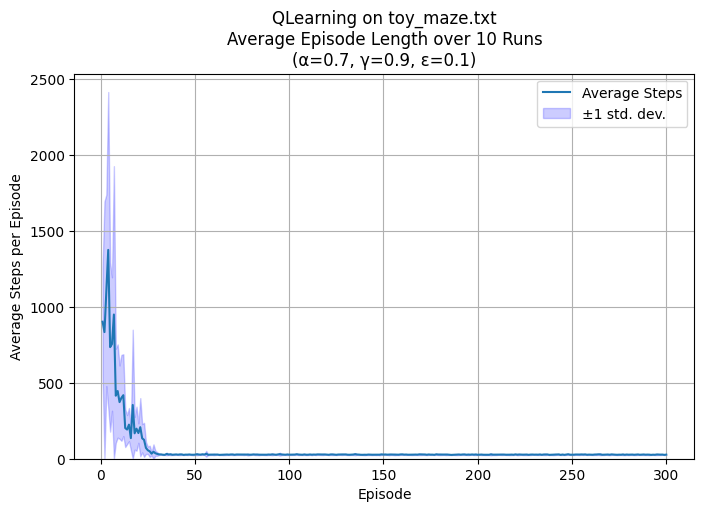


Evaluating SARSA on ./../data/toy_maze.txt


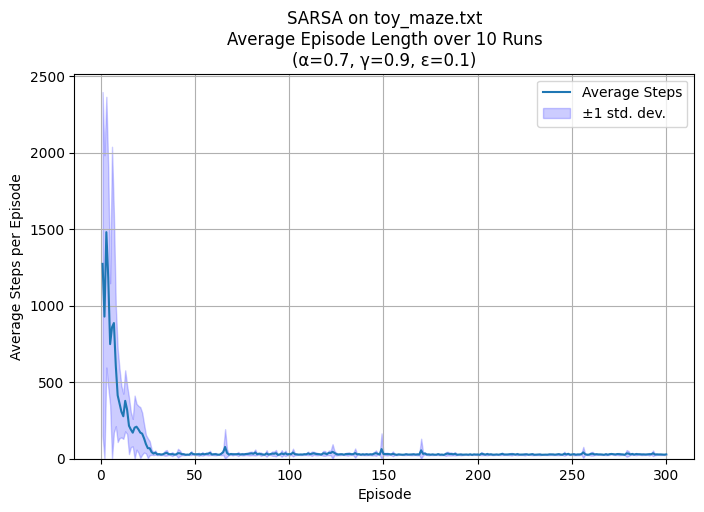


Evaluating QLearning on ./../data/easy_maze.txt


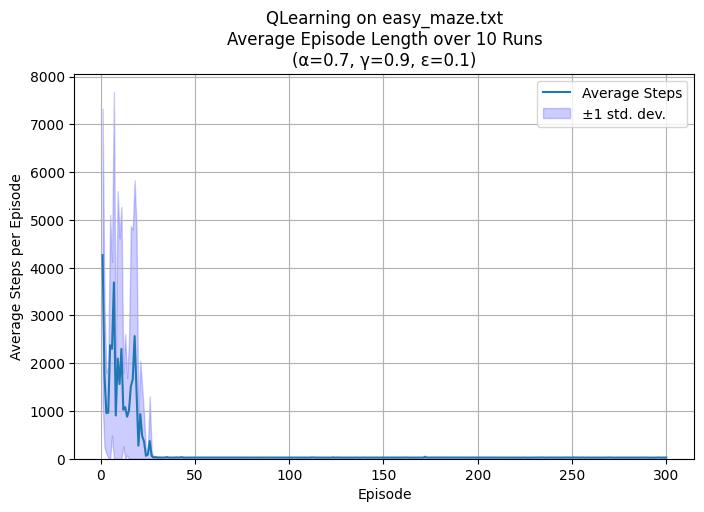


Evaluating SARSA on ./../data/easy_maze.txt


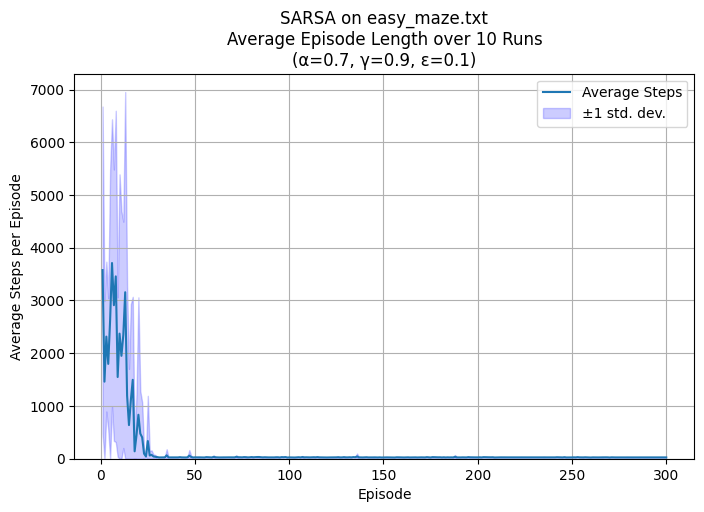

In [16]:
mazes_to_test = ["./../data/toy_maze.txt", "./../data/easy_maze.txt"]
algorithms = ["QLearning", "SARSA"]
params = {"alpha": 0.7, "gamma": 0.9}
runs = 10

plot_running_average(mazes_to_test, algorithms, params, runs)

**Conclusions**:

The plots clearly demonstrate that both the Q-Learning and SARSA agents successfully learn the environment. During the first 20-30 episodes, the average steps and standard deviation are high because the agents rely on random exploration (their Q-tables are essentially empty). However, the curves quickly flatline at a very low step count. The standard deviation also shrinks drastically, which means that the agents found a reliable path that they continue to use. 

Episode length drop reflects Q-table convergence. Q-values for states along the optimal path are updated upward, while the greedy component of ε-greedy increasingly selects those actions. As a result we are shortening the route the agent takes each episode.

We can observe that during the first episodes the agent requires significantly more steps in the easy maze than in the toy maze - that is likely because the easy maze is much larger, meaning the agent has a bigger state space to explore.


#### Question 7

From the graphs, QLearning and SARSA are very similar in final performance, but they differ slightly in learning dynamics.

In the **toy maze**, both converge quickly, but SARSA keeps small occasional spikes later in training, whereas QLearning looks slighly flatter after convergence; hence the main difference between the two is stability, and not final path quality.

In the **easy maze**, both methods start with very high average episode length and large variance, then rapidly drop and stabilize near short paths after roughly the first 25 episodes. QLearning appears slightly more aggressive in the early drop, while SARSA shows a bit more variability before fully flattening.

This lines up with the update rules for both methods:
- ***Q‑Learning*** uses the off‑policy target, so it updates toward the greedy next value even when the agent actually took an exploratory action. That usually makes value propagation a bit quicker.
- ***SARSA***, on the other hand, uses the on‑policy target. Because exploratory moves directly influence the update, SARSA ends up learning a slightly more cautious and noisier estimate of the policy it’s actually following.

Since both mazes are fairly simple and don’t heavily punish risky exploration, the two algorithms eventually settle on policies that are almost equally good. The main difference we see is in the early learning dynamics: speed and variance; rather than in the final outcome.


### 2.2 Optimization
#### Question 8


Evaluating QLearning on ./../data/toy_maze.txt


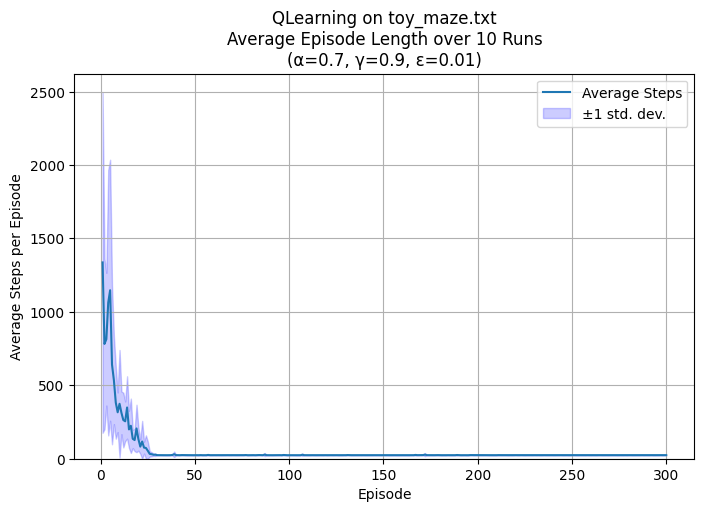


Evaluating QLearning on ./../data/toy_maze.txt


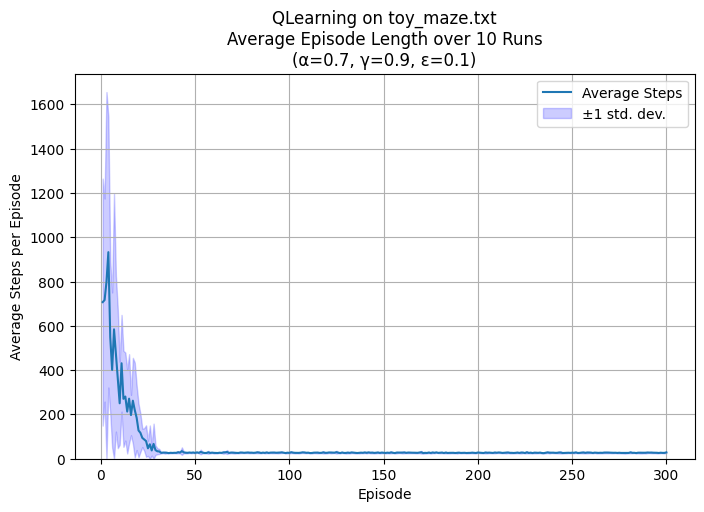


Evaluating QLearning on ./../data/toy_maze.txt


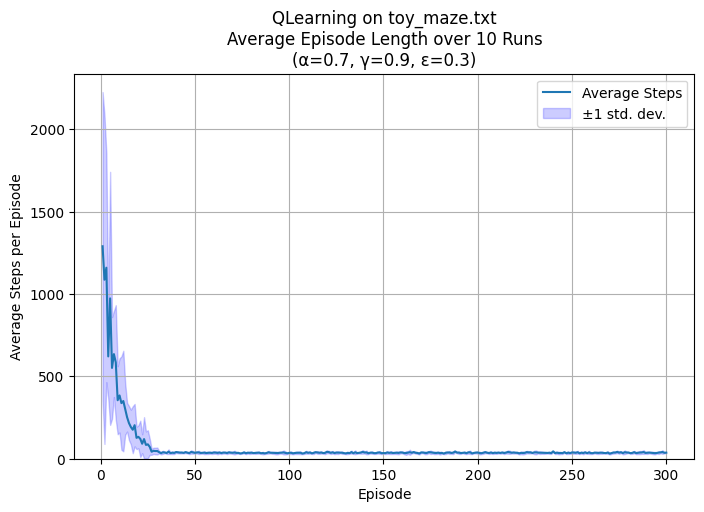


Evaluating QLearning on ./../data/toy_maze.txt


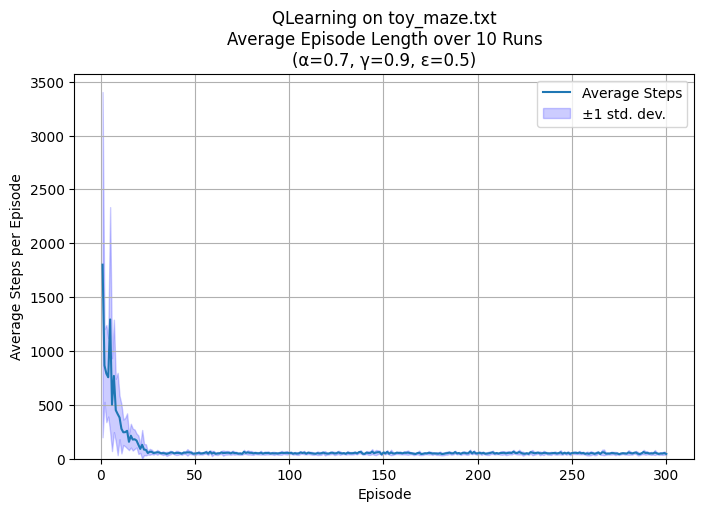


Evaluating QLearning on ./../data/toy_maze.txt


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


...

Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


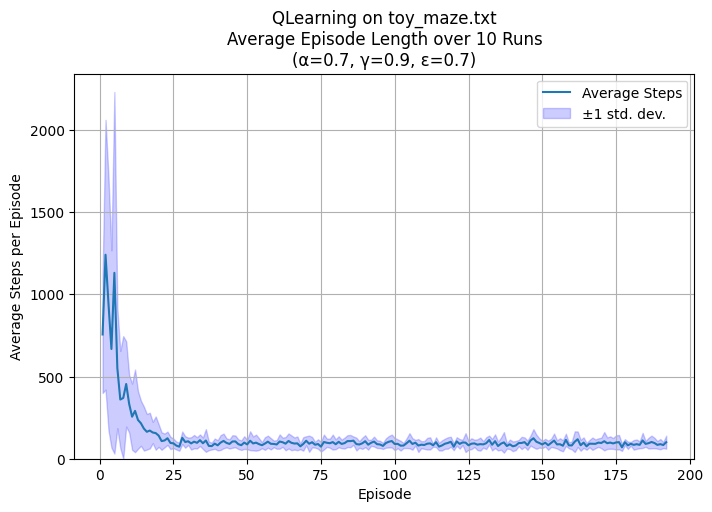


Evaluating QLearning on ./../data/toy_maze.txt


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


...

Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


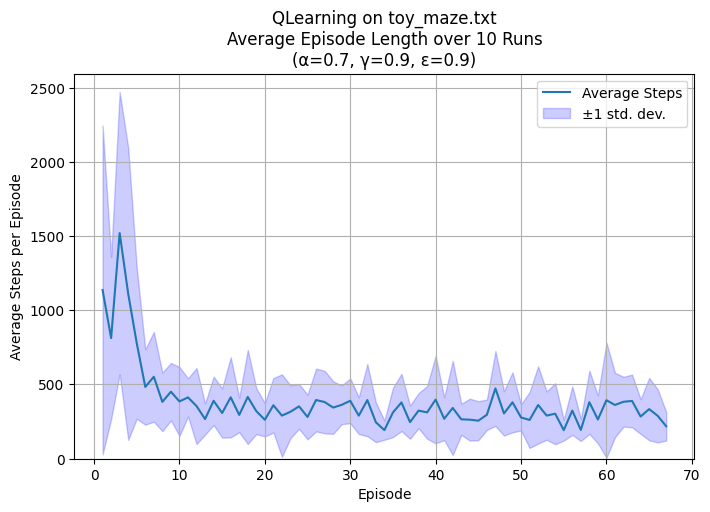

In [17]:
epsilons = [0.01, 0.1, 0.3, 0.5, 0.7, 0.9]
mazes_to_test = ["./../data/toy_maze.txt"]
algorithms = ["QLearning"]
params = {"alpha": 0.7, "gamma": 0.9}
runs = 10

for eps in epsilons:
    plot_running_average(mazes_to_test, algorithms, params, runs, eps = eps)

One observation would be that we can notice the higher the epsilon, the noisier the averages per episode. This is because a high epsilon means high exploration, while a low one means high exploitation. Take for example the first plot (eps = 0.01). It converges immediately, because it doesn't care to explore, it just wants to find a solution. This happens because even a single early episode is enough to assign positive Q-values to the states along the first discovered path. As we only have a 1% exploration budget remaining, the agent exploits that path on 99 out of every 100 steps. The finding of a better path with such limited exploration becomes negligible. 

The last plot (eps = 0.9), however, explores so much that the episodes take very long and we end up using all our 30000 steps in 80 episodes.

This doesn't necessarily mean high epsilon is worse: the model takes it's time to explore to find the best option, therefore having high number of steps per episode. In between, however, we can see that the model takes its time to explore, but also makes use of the good actions found so far.

#### Question 9

Lower values of ε (e.g., 0.01) favor exploitation: the agent quickly locks onto a good policy and follows it consistently, leading to short episodes. However, if the agent explores insufficiently early, it may converge to a suboptimal path. Higher values of ε (e.g., 0.9) favor exploration: the agent tries many actions and is likely to find the truly optimal path, but it never fully exploits what it learns—every episode remains long because random actions are taken frequently. The trade-off is between quick convergence to a possibly-suboptimal policy (low ε) versus slow episodes but guaranteed optimal learning (high ε).

#### Question 10


Evaluating QLearning on ./../data/toy_maze.txt


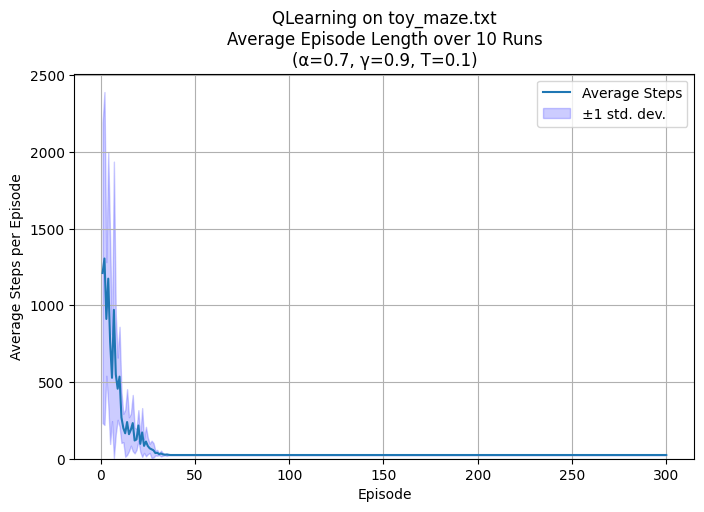


Evaluating QLearning on ./../data/toy_maze.txt


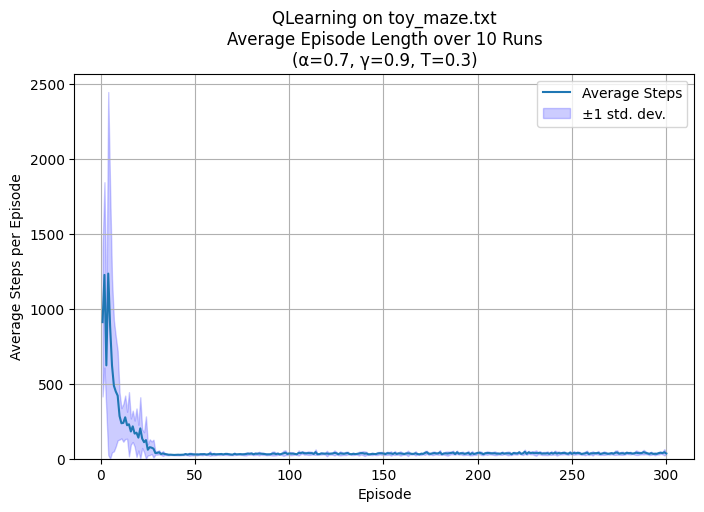


Evaluating QLearning on ./../data/toy_maze.txt


Early stop triggered at 30000 steps.


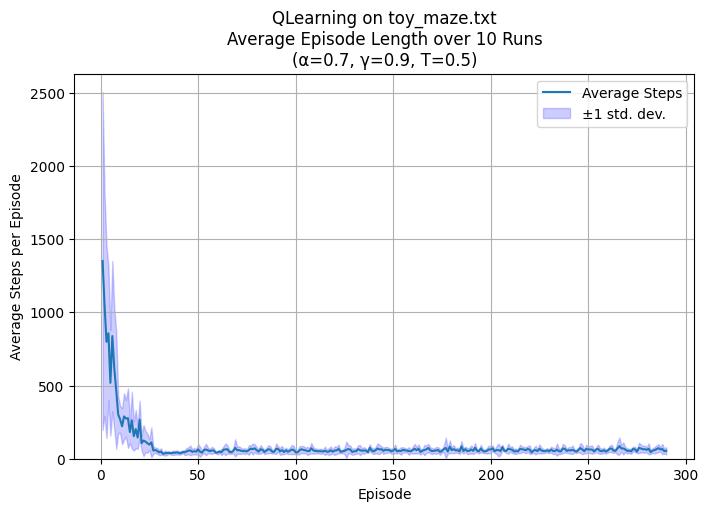


Evaluating QLearning on ./../data/toy_maze.txt


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


...

Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


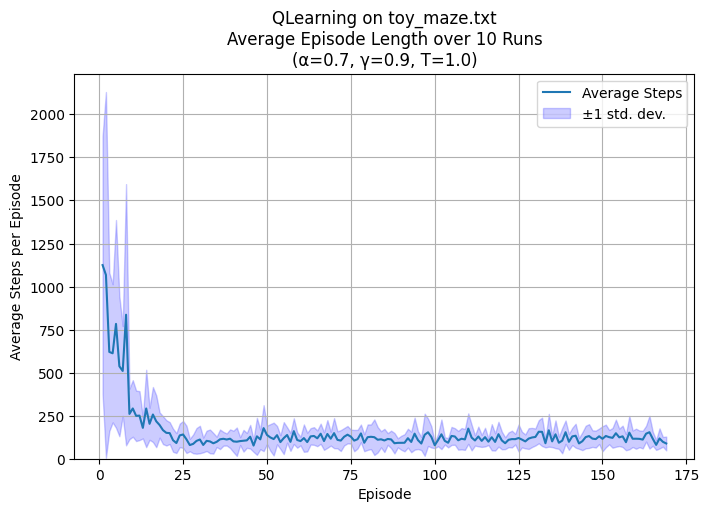


Evaluating QLearning on ./../data/toy_maze.txt


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


...

Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


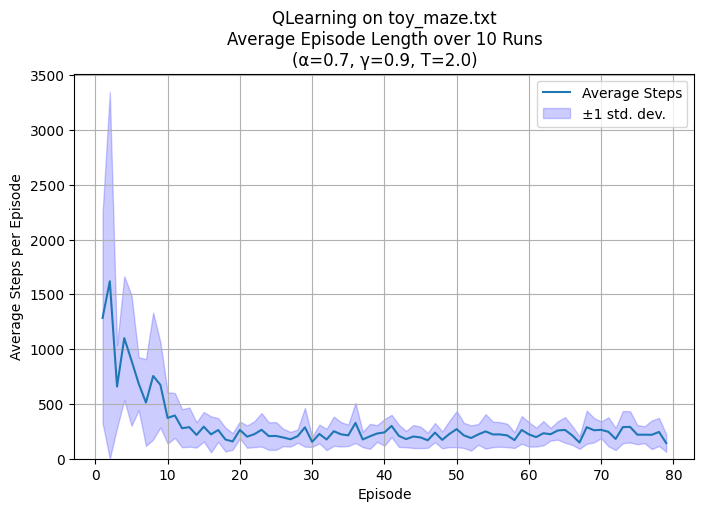

In [18]:
temperatures = [0.1, 0.3, 0.5, 1.0, 2.0]
runs = 10

for t in temperatures:
    plot_running_average(mazes_to_test, algorithms, params, runs, strategy = 2, temperature=t)

Let's think about what a low temperature in the Boltzmann equation actually means. exp(3 / 0.1) = exp(30), which is much higher than, let's say exp(2.5 / 0.1) = exp(25). So even if the values are really close, a small temperature will make the higher value be much more favourable than the other ones, almost in a greedy way.

On the other hand, a high temperature makes all values very similar, making the policy almost uniformly random. This is also visible in the plots, the higher the temperature, the more exploration and less exploitation, which is expected.

For small temperatures, the algorithm converges quickly, and for high temperatures, it explores for hundreds of steps every episode.

#### Question 11


Evaluating QLearning on ./../data/toy_maze.txt


Early stop triggered at 30000 steps.


Early stop triggered at 30000 steps.


Q-Learning:   0%|          | 0/300 [00:00<?, ?it/s]

Early stop triggered at 30000 steps.

...

Early stop triggered at 30000 steps.


Q-Learning:   0%|          | 0/300 [00:00<?, ?it/s]

Early stop triggered at 30000 steps.


Q-Learning:   0%|          | 0/300 [00:00<?, ?it/s]

Early stop triggered at 30000 steps.

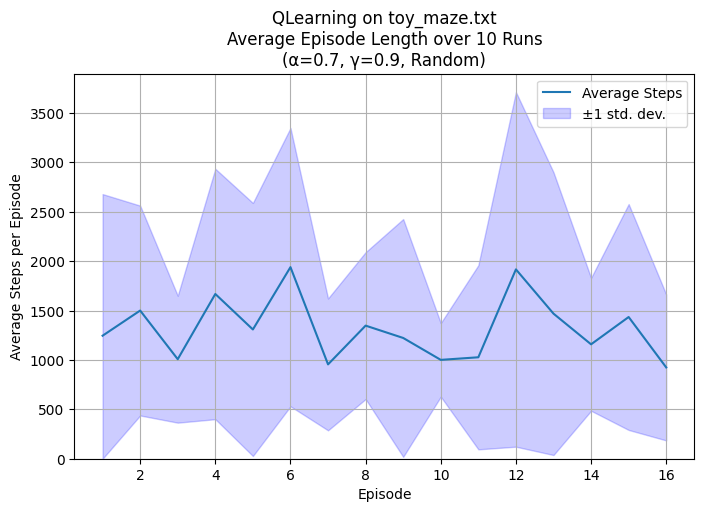


Evaluating QLearning on ./../data/toy_maze.txt


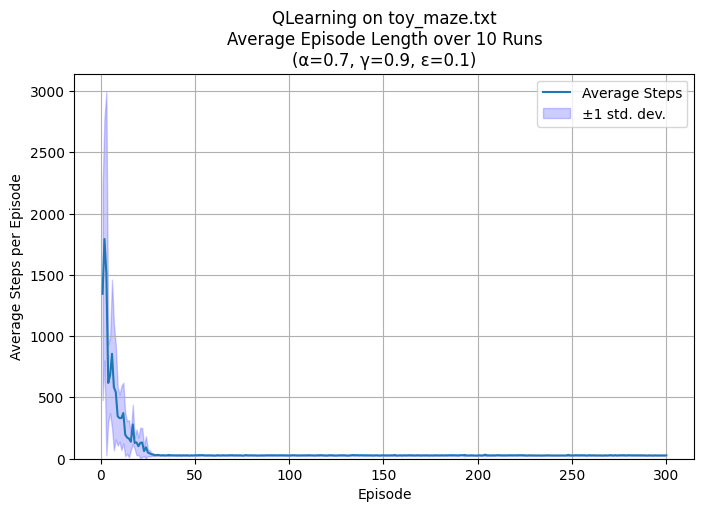


Evaluating QLearning on ./../data/toy_maze.txt


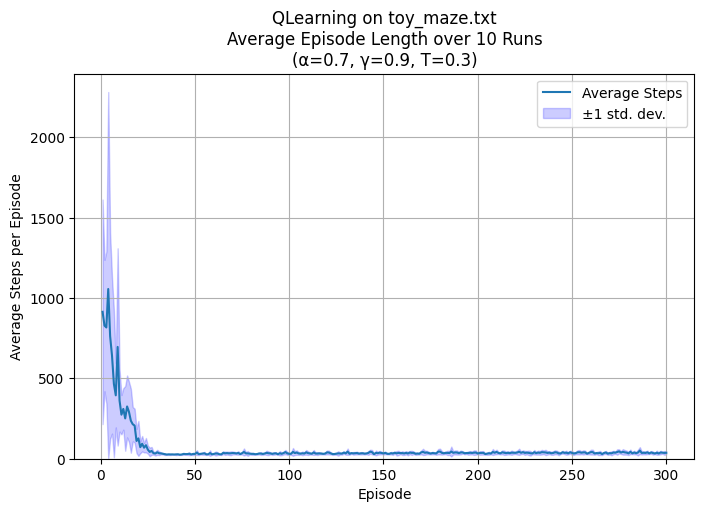

In [19]:
for i in range(3):
    plot_running_average(mazes_to_test, algorithms, params, runs, strategy = i, eps = 0.1, temperature=0.3)

Right off the bat, we notice random exploration is clearly inferior—it never learns anything because all actions are equally likely regardless of their Q-values, so it cannot build on accumulated knowledge.

As for the other 2 strategies, they're close but greedy is better than Boltzmann. This is because even though it's easy to implement, greedy is very effective to both explore and exploit. That also makes it fast to converge to the optimal solution. The discrete exploration provides stable learning. Once the agent finds the optimal path, it exploits it 90% of the time, resulting in consistently short episodes.

While Boltzmann also converges to optimal policies, ε-greedy converges faster. This is because Boltzmann's soft probabilistic approach continues to assign non-negligible probability to suboptimal actions even after learning.

#### Question 12


Evaluating QLearning on ./../data/toy_maze.txt


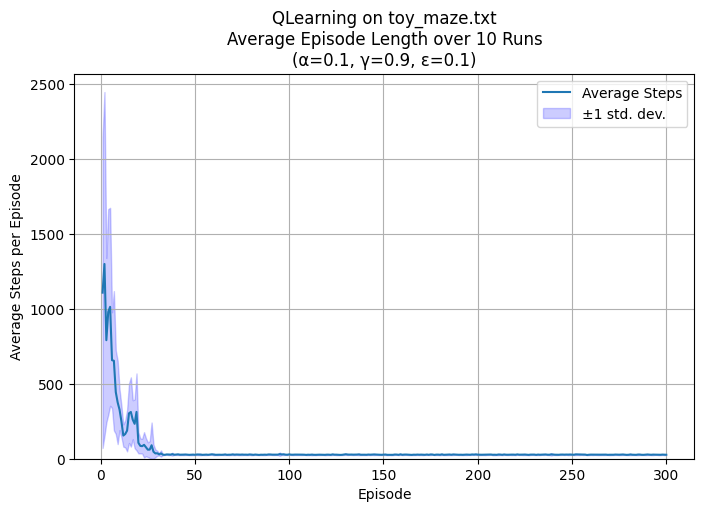


Evaluating QLearning on ./../data/toy_maze.txt


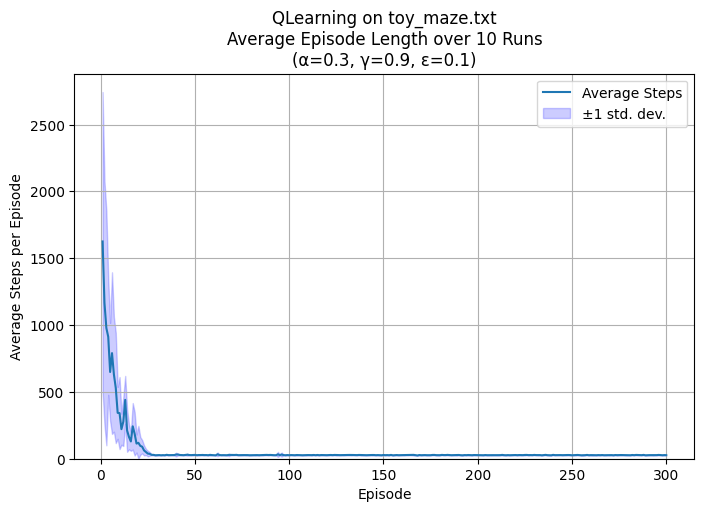


Evaluating QLearning on ./../data/toy_maze.txt


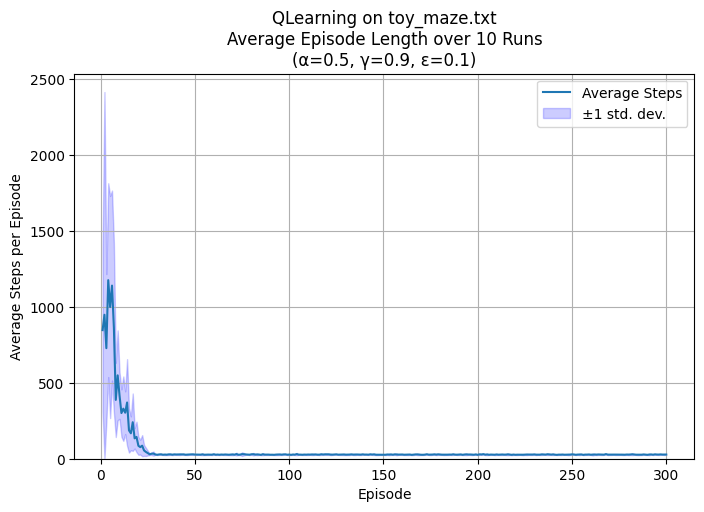


Evaluating QLearning on ./../data/toy_maze.txt


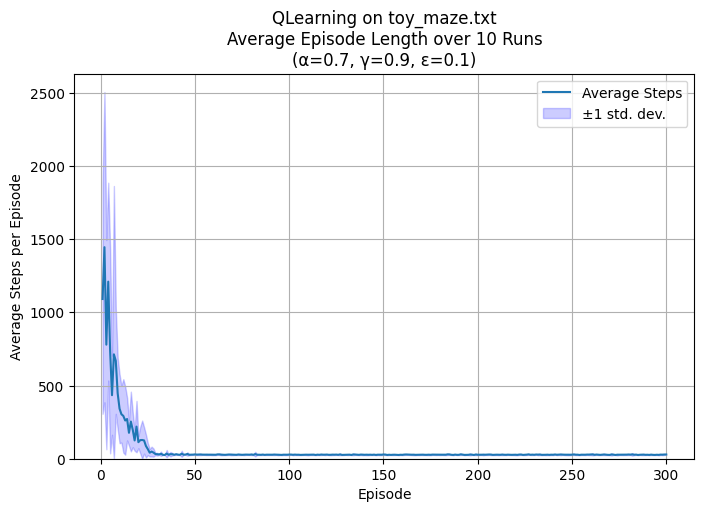


Evaluating QLearning on ./../data/toy_maze.txt


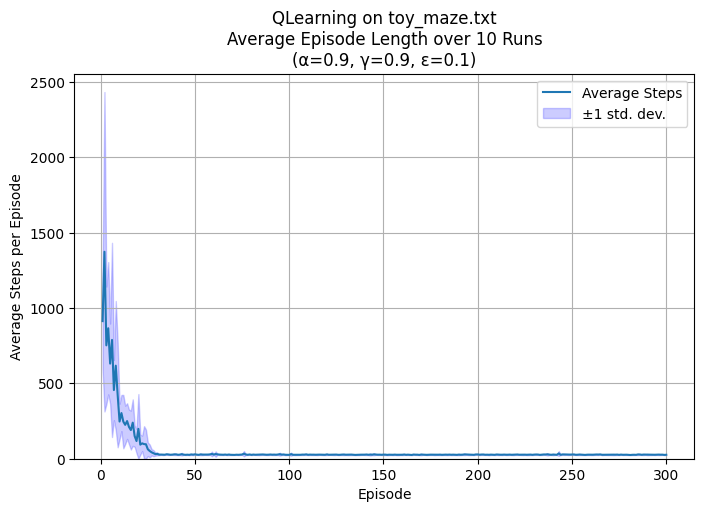

In [20]:
learning_rates = [0.1, 0.3, 0.5, 0.7, 0.9]
params = {"alpha": 0, "gamma": 0.9}
runs = 10

for lr in learning_rates:
    params["alpha"] = lr
    plot_running_average(mazes_to_test, algorithms, params, runs)

Lower α values (0.1) result in stable but slow convergence, taking many episodes to improve. Higher α values (0.9) show rapid initial improvement but become unstable and oscillate around the optimal policy. 

Large learning rates cause individual updates to overshoot the true Q-value and arises the instability at high α. The Q-value for the chosen action jumps past the optimum, making a different action appear best on the next visit. Consequently, it then also overshoots in opposite direction, producing continuous oscillation rather than convergence.

The optimal α appears to be around 0.7, which balances fast learning with stability.

### 2.3 Introducing More Rewards
#### Question 13

In [21]:
def make_environment_two_rewards(maze_path):
    maze = Maze(maze_path)
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)
    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)
    agent = Agent(start_x=0, start_y=0)
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)
    return maze, agent, q_table, exploration_strategy

# Convergence tracking
n_experiments = 30
converged_to = []

for run in range(n_experiments):
    global maze, agent, q_table, exploration_strategy
    maze, agent, q_table, exploration_strategy = make_environment_two_rewards("./../data/toy_maze.txt")
    
    learner = QLearning(q_table, {"alpha": 0.7, "gamma": 0.9})
    episode_lengths, episode_rewards = agent_cycle_qlearn(
        n_episodes=300, strategy=1, eps=0.1, learner=learner, steps_criterion=30000
    )
    
    avg_final_reward = np.mean(episode_rewards[-20:])
    converged_to.append(avg_final_reward)
    print(f"Run {run+1}: avg reward in last 20 episodes = {avg_final_reward:.2f}")

print(f"\nRuns converging to reward ~5:  {sum(1 for r in converged_to if r < 7)}")
print(f"Runs converging to reward ~10: {sum(1 for r in converged_to if r >= 7)}")

Run 1: avg reward in last 20 episodes = 5.00


Run 2: avg reward in last 20 episodes = 5.00


Run 3: avg reward in last 20 episodes = 10.00


Run 4: avg reward in last 20 episodes = 5.00


Run 5: avg reward in last 20 episodes = 5.00


...

Run 26: avg reward in last 20 episodes = 5.00


Run 27: avg reward in last 20 episodes = 5.00


Run 28: avg reward in last 20 episodes = 5.00


Run 29: avg reward in last 20 episodes = 10.00


Run 30: avg reward in last 20 episodes = 5.00

Runs converging to reward ~5:  27
Runs converging to reward ~10: 3


We added the second reward in the top-right corner with value of 5 at (9, 0), additionally we used the same hyper-parameters used in Q6. We ran 30 independent experiments to asses how did the inclusion of this new reward affect the behaviour of our agent. In the grand majority of our test runs, we observed that the agent converged to the new inferior reward of 5, with only a very few number of runs per experiment finding the optimal reward of 10. 

What we observe is premature convergence cause by the structure of the maze and the fixed exploration rate. As the agent starts with a completely empty Q-table and explores randomly, the new reward of 5 at (9, 0) is reachable simply by moving to the right repeatedly. It is a short and geometrically simple path that is explored very quickly in our random exploration. In contrast, navigating to the original bottom-right corner with reward 10 is a longer more complex route that needs to be followed, making it much less likely to actually be explored first. 

When the agent first discovers the suboptimal reward of 5, the values in the Q-table corresponding to that path become positive. As we have a low ε=0.1, our agent will exploit that path 90% of the time for all the remaining episodes in the run. As we now only have a 10% exploration budget, the agents becomes locked as it is too small to overcome the head start of the suboptimal reward. 

The failure now is due to the low ε that prevents sufficient exploration of new paths.


#### Question 14

QLearning: converged to reward ~5: 26, reward ~10: 4
SARSA: converged to reward ~5: 27, reward ~10: 3


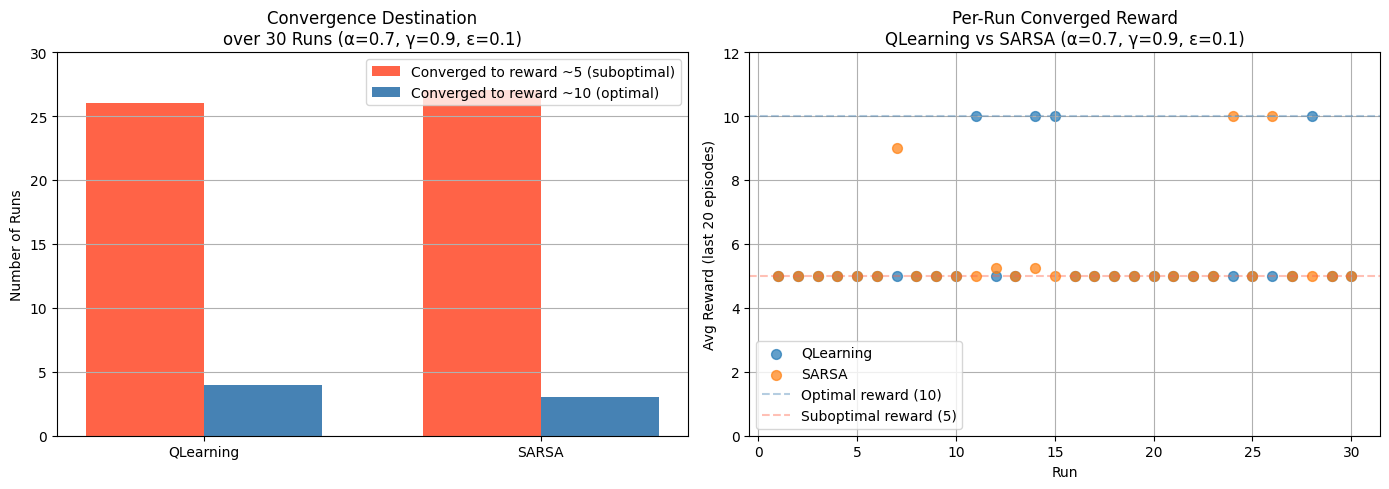

In [22]:
n_experiments = 30
results = {"QLearning": [], "SARSA": []}

for run in range(n_experiments):
    # Q-Learning
    maze, agent, q_table, exploration_strategy = make_environment_two_rewards("./../data/toy_maze.txt")
    learner = QLearning(q_table, {"alpha": 0.7, "gamma": 0.9})
    _, episode_rewards = agent_cycle_qlearn(
        n_episodes=300, strategy=1, eps=0.1, learner=learner, steps_criterion=30000
    )
    results["QLearning"].append(np.mean(episode_rewards[-20:]))

    # SARSA
    maze, agent, q_table, exploration_strategy = make_environment_two_rewards("./../data/toy_maze.txt")
    learner = SARSA(q_table, {"alpha": 0.7, "gamma": 0.9})
    _, episode_rewards = agent_cycle_sarsa(
        n_episodes=300, strategy=1, eps=0.1, learner=learner, steps_criterion=30000
    )
    results["SARSA"].append(np.mean(episode_rewards[-20:]))

# Print summary
for algo, rewards in results.items():
    n_suboptimal = sum(1 for r in rewards if r < 7)
    n_optimal = sum(1 for r in rewards if r >= 7)
    print(f"{algo}: converged to reward ~5: {n_suboptimal}, reward ~10: {n_optimal}")

# Plot 1: Bar chart comparing convergence counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

algorithms = ["QLearning", "SARSA"]
suboptimal_counts = [sum(1 for r in results[a] if r < 7) for a in algorithms]
optimal_counts    = [sum(1 for r in results[a] if r >= 7) for a in algorithms]

x = np.arange(len(algorithms))
width = 0.35

axes[0].bar(x - width/2, suboptimal_counts, width, label='Converged to reward ~5 (suboptimal)', color='tomato')
axes[0].bar(x + width/2, optimal_counts,    width, label='Converged to reward ~10 (optimal)',   color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(algorithms)
axes[0].set_ylabel('Number of Runs')
axes[0].set_title(f'Convergence Destination\nover {n_experiments} Runs (α=0.7, γ=0.9, ε=0.1)')
axes[0].set_ylim(0, n_experiments)
axes[0].legend()
axes[0].grid(True, axis='y')

# Plot 2: Reward distribution per run as a scatter plot
for i, algo in enumerate(algorithms):
    axes[1].scatter(
        range(1, n_experiments + 1),
        results[algo],
        label=algo,
        alpha=0.7,
        s=50
    )

axes[1].axhline(y=10, color='steelblue', linestyle='--', alpha=0.4, label='Optimal reward (10)')
axes[1].axhline(y=5,  color='tomato',    linestyle='--', alpha=0.4, label='Suboptimal reward (5)')
axes[1].set_xlabel('Run')
axes[1].set_ylabel('Avg Reward (last 20 episodes)')
axes[1].set_title(f'Per-Run Converged Reward\nQLearning vs SARSA (α=0.7, γ=0.9, ε=0.1)')
axes[1].set_ylim(0, 12)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

We run both algorithms side-by-side 30 times under identical hyper-parameters. Both methods, Q-Learning and SARSA converge in the vast majority of runs to the suboptimal reward of 5. Only a small amount of runs in each experiment actually converge to the optimal result of 10. We can observe this in the bar chart clearly, where both algorithms have an extremely small 10-reward convergence (blue) against 5-reward convergence (red). The scatter plot further confirms the visual, almost every point plotted in the graph corresponds to 5-reward instead of 10-reward optimal. 

Using SARSA instead of Q-Learning does not help. Q-Learning uses the theoretical best next action, while SARSA uses the action actually to be taken. This makes SARSA more conservative by accounting for exploratory actions in its updates. This would be very beneficial in mazes where there are risky paths, for instance in mazes that have large penalties in paths surrounding the optimal path. However, as this maze does not contain any of this features, it is not helpful.

Having two rewards in the map makes it exactly about which of them gets discovered first during the early stages of random exploration. As both Q-Learning and SARSA use the same ε-greedy strategy with ε=0.1, they explore in the exact same way. This means that the Q-value update rule has no influence over the states that get visited. Both strategies suffer from premature convergence for the same reasons. 

#### Question 15


Runs converging to reward ~5:  0
Runs converging to reward ~10: 30


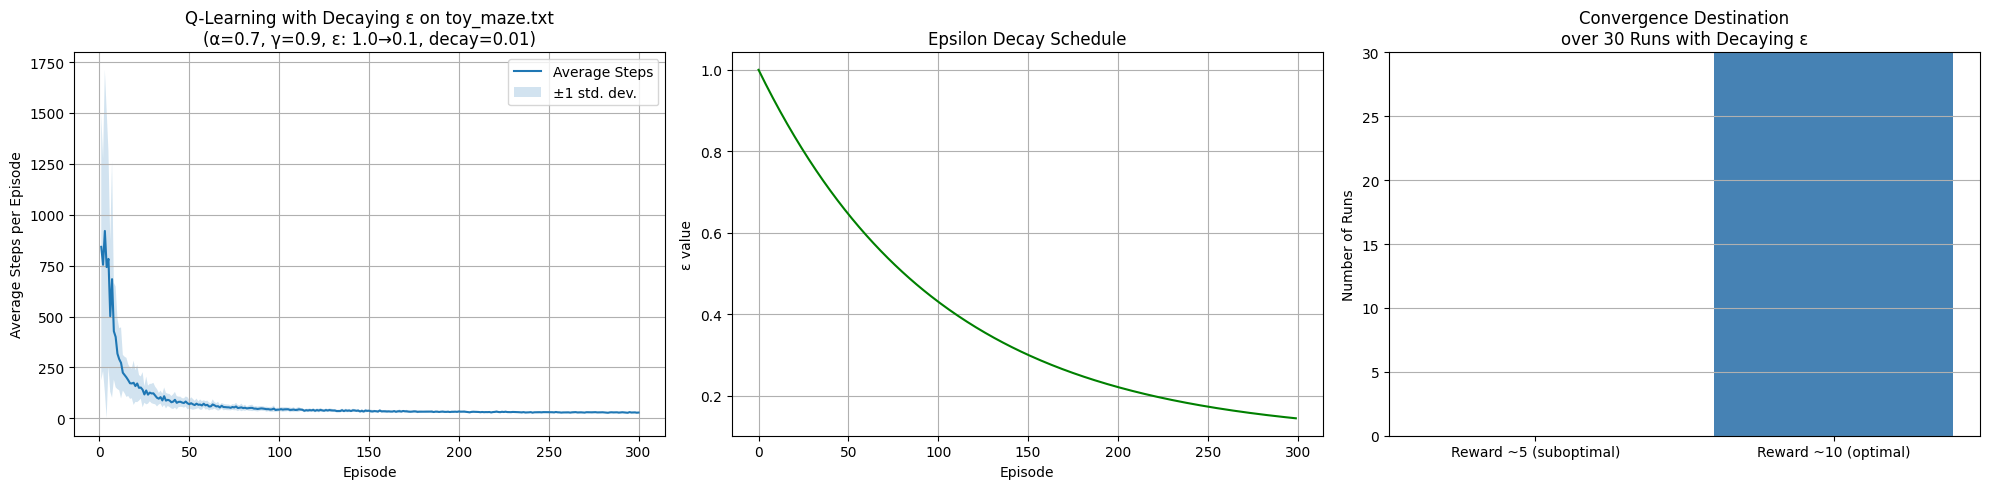

In [23]:
def agent_cycle_qlearn_decay(n_episodes=300, eps_start=1.0, eps_min=0.1, 
                              decay_rate=0.005, learner=None, steps_criterion=30000):
    episode_lengths = []
    episode_rewards = []
    total_steps = 0
    epsilons = []
    for episode in tqdm(range(n_episodes), desc="Q-Learning decay", leave=False):
        eps = eps_min + (eps_start - eps_min) * np.exp(-decay_rate * episode)
        epsilons.append(eps)
        agent.reset()
        total_reward = 0
        total_length = 0
        current_state = agent.get_state(maze=maze)
        while not current_state.done:
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)
            next_state, reward, done = agent.step(action, maze)
            total_steps += 1
            if learner is not None:
                next_possible_actions = agent.get_valid_actions(maze=maze) if not done else []
                learner.learn(next_possible_actions, current_state, action, next_state, reward, done)
            total_reward += reward
            total_length += 1
            current_state = next_state
            if total_steps >= steps_criterion:
                break
        episode_rewards.append(total_reward)
        episode_lengths.append(total_length)
        if total_steps >= steps_criterion:
            break
    return episode_lengths, episode_rewards, epsilons

# --- Experiment ---
n_experiments = 30
converged_to = []
all_lengths = []

eps_start = 1.0
eps_min = 0.1
decay_rate = 0.01

for run in range(n_experiments):
    global maze, agent, q_table, exploration_strategy
    maze, agent, q_table, exploration_strategy = make_environment_two_rewards("./../data/toy_maze.txt")
    learner = QLearning(q_table, {"alpha": 0.7, "gamma": 0.9})
    episode_lengths, episode_rewards, epsilons = agent_cycle_qlearn_decay(
        n_episodes=300,
        eps_start=eps_start,
        eps_min=eps_min,
        decay_rate=decay_rate,
        learner=learner,
        steps_criterion=30000
    )
    all_lengths.append(episode_lengths)
    converged_to.append(np.mean(episode_rewards[-20:]))

print(f"\nRuns converging to reward ~5:  {sum(1 for r in converged_to if r < 7)}")
print(f"Runs converging to reward ~10: {sum(1 for r in converged_to if r >= 7)}")

# --- Plots ---
min_episodes = min(len(l) for l in all_lengths)
avg_lengths = np.array([np.mean([l[ep] for l in all_lengths]) for ep in range(min_episodes)])
std_lengths = np.array([np.std([l[ep]  for l in all_lengths]) for ep in range(min_episodes)])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Learning curve
axes[0].plot(range(1, min_episodes + 1), avg_lengths, label='Average Steps')
axes[0].fill_between(
    range(1, min_episodes + 1),
    np.maximum(0, avg_lengths - std_lengths),
    avg_lengths + std_lengths,
    alpha=0.2, label='±1 std. dev.'
)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Average Steps per Episode')
axes[0].set_title(f'Q-Learning with Decaying ε on toy_maze.txt\n'
                  f'(α=0.7, γ=0.9, ε: {eps_start}→{eps_min}, decay={decay_rate})')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Epsilon decay curve
axes[1].plot(range(len(epsilons)), epsilons, color='green')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('ε value')
axes[1].set_title('Epsilon Decay Schedule')
axes[1].grid(True)

# Plot 3: Bar chart of convergence destination (same style as Q14)
suboptimal_count = sum(1 for r in converged_to if r < 7)
optimal_count    = sum(1 for r in converged_to if r >= 7)

axes[2].bar(['Reward ~5 (suboptimal)', 'Reward ~10 (optimal)'],
            [suboptimal_count, optimal_count],
            color=['tomato', 'steelblue'])
axes[2].set_ylabel('Number of Runs')
axes[2].set_title(f'Convergence Destination\nover {n_experiments} Runs with Decaying ε')
axes[2].set_ylim(0, n_experiments)
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.show()

As we can observe from the results above the success rate for converging to 10-reward is extremely higher. Due to the stochastic nature of the algorithm we observe some variance from run to run, but the very low number of convergence to 5-reward is a general remark to be made in every run.

The approach we used is exponential ε-Decay. We implemented an exponentially decaying ε schedule, a technique described in the RL literature (Sutton & Barto, 2018, Chapter 2): 

$$\varepsilon_t = \varepsilon_{min} + (\varepsilon_{0} - \varepsilon_{min}) \cdot e^{-\lambda \cdot t}$$

where 

$\varepsilon_0 = 1.0$

$\varepsilon_{min}=0.1$

$\varepsilon_{decay} (λ) = 0.01$

and t is the current episode number.


This approach helps because both exploration and exploitation are needed at different stages of learning. At the start of the run our agent knows nothing, having a high ε ensures we allow it to explore the maze and reliably discover both rewards in the maze before committing to either one of them. We make ε decay exponentially, gradually making the agent shift from exploration to exploitation of the best found policy. As a remark, ε never falls beneath 0.1 as we need to ensure some minimum exploration is always maintained.

As we saw in Q13, maintaining a fixed ε=0.1 locks the agent into the first found reward, almost always exploiting suboptimal 5-reward. With the decaying ε, our agent can escape this and maintain a high-exploration mode specially in the beginning phases, making it very more likely to discover the 10-reward. We observe this in our plots where the learning curve shows high variance and many steps in early episodes in the exploration phase, followed by convergence as ε decays and the agent exploits the optimal path.

Reference:
Sutton, R. S., & Barto, A. G. (2018). Reinforcement Learning: An Introduction (2nd ed.). MIT Press.

#### Question 16

In [24]:
from collections import deque

def bfs_shortest_path(maze, start_x, start_y, target_x, target_y):
    """BFS to find shortest path length between two points in the maze."""
    queue = deque()
    queue.append((start_x, start_y, 0))
    visited = set()
    visited.add((start_x, start_y))
    
    while queue:
        x, y, steps = queue.popleft()
        
        if x == target_x and y == target_y:
            return steps
        
        # up, down, left, right as coordinate deltas
        for dx, dy in [(0, -1), (0, 1), (-1, 0), (1, 0)]:
            new_x, new_y = x + dx, y + dy
            
            if (maze.check_bounds(new_x, new_y) and 
                maze.is_walkable(new_x, new_y) and 
                (new_x, new_y) not in visited):
                visited.add((new_x, new_y))
                queue.append((new_x, new_y, steps + 1))
    
    return None

# Use a fresh maze to find actual path lengths
temp_maze, _, _, _ = make_environment_two_rewards("./../data/toy_maze.txt")

d1 = bfs_shortest_path(temp_maze, 0, 0, 9, 0)  # start to reward 5
d2 = bfs_shortest_path(temp_maze, 0, 0, 9, 9)  # start to reward 10

print(f"Shortest path to reward 5  at (9,0): {d1} steps")
print(f"Shortest path to reward 10 at (9,9): {d2} steps")
print(f"Theoretical threshold: γ < (1/2)^(1/{d2-d1}) = {(0.5)**(1/(d2-d1)):.4f}")

Shortest path to reward 5  at (9,0): 21 steps
Shortest path to reward 10 at (9,9): 24 steps
Theoretical threshold: γ < (1/2)^(1/3) = 0.7937


γ=0.6000: reward~5: 30, reward~10: 0


γ=0.7000: reward~5: 30, reward~10: 0


γ=0.7500: reward~5: 30, reward~10: 0


γ=0.7800: reward~5: 30, reward~10: 0


γ=0.7900: reward~5: 30, reward~10: 0


...

γ=0.7937: reward~5: 30, reward~10: 0


γ=0.7950: reward~5: 1, reward~10: 29


γ=0.8000: reward~5: 1, reward~10: 29


γ=0.8500: reward~5: 1, reward~10: 29


γ=0.9000: reward~5: 1, reward~10: 29


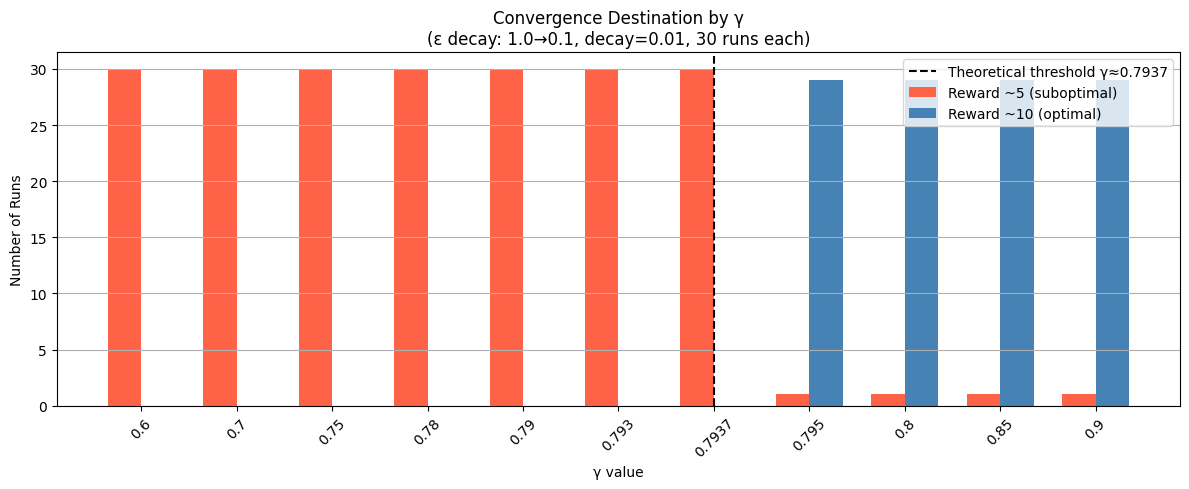

In [25]:
gammas = [0.60, 0.70, 0.75, 0.78, 0.79, 0.793, 0.7937, 0.795, 0.80, 0.85, 0.90]
n_experiments = 30
results_by_gamma = {}

for gamma in gammas:
    converged_to = []
    for run in range(n_experiments):
        global maze, agent, q_table, exploration_strategy
        maze, agent, q_table, exploration_strategy = make_environment_two_rewards("./../data/toy_maze.txt")
        learner = QLearning(q_table, {"alpha": 0.7, "gamma": gamma})
        episode_lengths, episode_rewards, epsilons = agent_cycle_qlearn_decay(
            n_episodes=300,
            eps_start=1.0,
            eps_min=0.1,
            decay_rate=0.01,
            learner=learner,
            steps_criterion=30000
        )
        converged_to.append(np.mean(episode_rewards[-20:]))
    
    n_suboptimal = sum(1 for r in converged_to if r < 7)
    n_optimal    = sum(1 for r in converged_to if r >= 7)
    results_by_gamma[gamma] = (n_suboptimal, n_optimal)
    print(f"γ={gamma:.4f}: reward~5: {n_suboptimal}, reward~10: {n_optimal}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

suboptimal_counts = [results_by_gamma[g][0] for g in gammas]
optimal_counts    = [results_by_gamma[g][1] for g in gammas]
x = np.arange(len(gammas))
width = 0.35

ax.bar(x - width/2, suboptimal_counts, width, label='Reward ~5 (suboptimal)', color='tomato')
ax.bar(x + width/2, optimal_counts,    width, label='Reward ~10 (optimal)',   color='steelblue')
ax.axvline(x=gammas.index(0.7937), color='black', linestyle='--', label='Theoretical threshold γ≈0.7937')
ax.set_xticks(x)
ax.set_xticklabels([str(g) for g in gammas], rotation=45)
ax.set_xlabel('γ value')
ax.set_ylabel('Number of Runs')
ax.set_title(f'Convergence Destination by γ\n(ε decay: 1.0→0.1, decay=0.01, 30 runs each)')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

We test a range of γ values around the expected/predicted threshold. We continue to use the ε-decay strategy with the same ε hyper-parameter values. The plot show a clear transition, values up to and including 0.7937 converge to 5-reward, while above 0.795 they converge to 10-reward. The exact value varies slightly per run between those values due to the stochastic nature of the algorithm, but it consistently places them in between them. 


To find the threshold analytically, we used BFS to determine the shortest paths to the rewards. 
Shortest path from (0,0) to reward 5 at (9,0): d₁ = 21 steps
Shortest path from (0,0) to reward 10 at (9,9): d₂ = 24 steps


The discounted value of each reward along its optimal path is:

$$V_5 = \gamma^{21} \cdot 5 \qquad V_{10} = \gamma^{24} \cdot 10$$

The agent prefers reward 5 when $V_5 > V_{10}$:

$$\gamma^{21} \cdot 5 > \gamma^{24} \cdot 10$$

Dividing both sides by $\gamma^{21}$ (valid since $\gamma > 0$):

$$5 > \gamma^{3} \cdot 10$$

$$\gamma^{3} < \frac{1}{2}$$

$$\gamma < \left(\frac{1}{2}\right)^{1/3} \approx 0.7937$$

The theoretical threshold of y = 0.7937 is confirmed experimentally. A low γ discounts future rewards, making the slightly shorter path to 5-reward worth more. Above the threshold, the discount is low enough that the extra steps are worth taking. 

## 3. Open Questions
### 3.1 Reflection
#### Question 17

One downside of a purely greedy algorithm is that it always selects the action with the highest estimated Q-value and never explores alternatives. This means once it finds an action that yields decent rewards, it commits to it entirely and never discovers if better options exist. The agent gets trapped in local optima.

A solution to this is to use epsilon-greedy, implemented in this assignment, that is only greedy with a certain probability. This way, we both explore and also exploit the best solution yet.

#### Question 18

Reward functions can cause problems when an agent optimises the specific metric perfectly but misses the underlying goal of why that metric was used. This is called reward hacking or Goodhart's Law. 

For instance, an example is social media recommendation algorithms. They are trained using RL-styled reward functions, based on engagement with the content, likes, shares etc... The agent maximises this reward function very efficiently, but what is discovered is that provocative, controversial and radical content produces way more engagement than balanced and informative content. The underlying goal of social media was to connect and inform people, but the results have been increased polarisation, radicalisation and misinformation. This was due to the agent perfectly optimising the reward function but missing the underlying goal entirely. 

The issue that we face is that rewards functions are only a proxy for what we really want to achieve. As agents and algorithms have no notion of this, they end up exploiting the gap between the proxy metric and the real goal.

#### Question 19

There are several approaches tha can be tried to mitigate the reward misspecification issue. 

For instance, Reinforcement Learning from Human Feedback, this trains the model directly on human preferences. Skipping the specification of what needs to be optimised, the agent's behaviour is rated differently, and the reward model learns the judgments directly. As a benefit we can implicitly encode intent, context and ethics into the agent that is not possible to do mathematically. However, it also comes with risks, like biases in human evaluations or inconsistencies.

Alternatively, we can use other approach like Constrained Reinforcement Learning with hard constraints in the reward function like agents not being able to violate certain rules regardless of reward gains. For instance, making reference to Q18, we could to constrain the model to not recommend misinformation although it would push reward gains upwards. This isolates safety from optimisation objectives.

Lastly, we can also use Inverse Reinforcement Learning. This takes the opposite approach entirely, the agent observes human behaviour, and then the agent infers the reward function from that. We assume that the humans act approximately optimally w.r.t. their preferences, so their behaviour reveals the preferences implicitly. This avoids manually specifying a reward function entirely.

Of course, every solution comes with trade offs and we have to prioritise what is the best approach for each situation we face.

### 3.2 Pen and Paper
#### Question 20


![Q_20](Q_20.png)


**States**:
- E - at the entrance without holding anything (starting point)
- A - at the aisle without holding anything
- C - at the cash register without holding anything
- EB2 - at the entrance holding 2 packs of berries
- AB2 - at the aisle holding 2 packs of berries
- CB2 - at the cash register holding 2 packs of berries
- EB1, AB1, CB1 - same as above but with 1 pack of berries
- EAP, AAP, CAP - same as above but with apples
- T - terminal state
	
**Actions**:
- F - move forward
- R - move backwards
- A - pick up apples
- B - pick up berries
- P - pay


**Remarks**:

F, 0.9, r=0 - move forward with probability 0.9 and result in reward 0.

As stated in the exercise, to avoid clustering, we omitted actions that do not change the state of the robot and just result in a "wasted" move (r = -1). However we did include the penalty caused by actuators failing in the state E to show understanding of how it would look like. Such transitions should be included in every state. Moreover, we included the penalty for spilling berries, as it results in a penalty of -2. 

#### Question 21

![Q_20](Q_21.png)


**Note**: The policy is only represented by the first 2 columns, as it just maps a satte to an action. The rest of the table is just to help with calculations.

Iteration 0 (initialization):

$$
\begin{aligned}
v_0(E) &= 0 \\
v_0(A) &= 0 \\
v_0(C) &= 0 \\
v_0(EB1) &= 0 \\
v_0(AB1) &= 0 \\
v_0(CB1) &= 0 \\
v_0(EB2) &= 0 \\
v_0(AB2) &= 0 \\
v_0(CB2) &= 0 \\
v_0(EAP) &= 0 \\
v_0(AAP) &= 0 \\
v_0(CAP) &= 0 \\
v_0(T) &= 0
\end{aligned}
$$

Iteration 1:

$$
\begin{aligned}
v_1(E) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(E)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(A) &= 1.0 \cdot [0 + 0.9 \cdot v_0(AB1)] = 1.0 \cdot [0 + 0.9 \cdot 0] = 0 \\
v_1(C) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(C)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(EB1) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(EB1)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(AB1) &= 0.8 \cdot [0 + 0.9 \cdot v_0(AB2)] + 0.2 \cdot [-2 + 0.9 \cdot v_0(AB1)] \\
&= 0.8 \cdot 0 + 0.2 \cdot (-2) \\
&= -0.4 \\
v_1(CB1) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(CB1)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(EB2) &= 0.9 \cdot [0 + 0.9 \cdot v_0(AB2)] + 0.1 \cdot [-1 + 0.9 \cdot v_0(EB2)] \\
&= 0.9 \cdot 0 + 0.1 \cdot (-1) \\
&= -0.1 \\
v_1(AB2) &= 0.9 \cdot [0 + 0.9 \cdot v_0(CB2)] + 0.1 \cdot [-1 + 0.9 \cdot v_0(AB2)] \\
&= 0.9 \cdot 0 + 0.1 \cdot (-1) \\
&= -0.1 \\
v_1(CB2) &= 1.0 \cdot [10 + 0.9 \cdot v_0(T)] = 1.0 \cdot [10 + 0] = 10 \\
v_1(EAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(EAP)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(AAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(AAP)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(CAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_0(CAP)] = 1.0 \cdot [-1 + 0.9 \cdot 0] = -1 \\
v_1(T) &= v_0(T) = 0
\end{aligned}
$$

Iteration 2:

$$
\begin{aligned}
v_2(E) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(E)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(A) &= 1.0 \cdot [0 + 0.9 \cdot v_1(AB1)] = 0.9 \cdot (-0.4) = -0.36 \\
v_2(C) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(C)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(EB1) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(EB1)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(AB1) &= 0.8 \cdot [0 + 0.9 \cdot v_1(AB2)] + 0.2 \cdot [-2 + 0.9 \cdot v_1(AB1)] \\
&= 0.8 \cdot (0.9 \cdot (-0.1)) + 0.2 \cdot (-2 + 0.9 \cdot (-0.4)) \\
&= 0.8 \cdot (-0.09) + 0.2 \cdot (-2.36) \\
&= -0.072 - 0.472 = -0.544 \\
v_2(CB1) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(CB1)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(EB2) &= 0.9 \cdot [0 + 0.9 \cdot v_1(AB2)] + 0.1 \cdot [-1 + 0.9 \cdot v_1(EB2)] \\
&= 0.9 \cdot (0.9 \cdot (-0.1)) + 0.1 \cdot (-1 + 0.9 \cdot (-0.1)) \\
&= 0.9 \cdot (-0.09) + 0.1 \cdot (-1.09) \\
&= -0.081 - 0.109 = -0.19 \\
v_2(AB2) &= 0.9 \cdot [0 + 0.9 \cdot v_1(CB2)] + 0.1 \cdot [-1 + 0.9 \cdot v_1(AB2)] \\
&= 0.9 \cdot (0.9 \cdot 10) + 0.1 \cdot (-1 + 0.9 \cdot (-0.1)) \\
&= 0.9 \cdot 9 + 0.1 \cdot (-1.09) \\
&= 8.1 - 0.109 = 7.991 \\
v_2(CB2) &= 1.0 \cdot [10 + 0.9 \cdot v_1(T)] = 10 + 0 = 10 \\
v_2(EAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(EAP)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(AAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(AAP)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2(CAP) &= 1.0 \cdot [-1 + 0.9 \cdot v_1(CAP)] = -1 + 0.9 \cdot (-1) = -1.9 \\
v_2​(T) &=v_1​(T)=0
\end{aligned}
$$

#### Question 22

In order to find the optimal policy, we can use **value iteration**. We run the 
Bellman optimality equation repeatedly for all states until the values converge 
(improvement stays below a threshold for consecutive iterations):

$$v_{k+1}(s) = \max_{a} \sum_{s'} P(s' \mid s, a) \left[ R(s, a, s') + \gamma v_k(s') \right]$$

Instead of following a fixed policy like in Q21, we take the max over all actions 
at each state. At every iteration, for every state, we try all possible actions 
and keep the one with the highest expected value.

Similarly to Q21, we start with $v_0(s) = 0$. At the end we pick the policy 
greedily - at each state, take whichever action gave the maximum.

### 3.3 Division of Work

#### Question 23




|          Component          |   Tudor   |   Luca    | Alejandro |   Adam    |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |    25%    |    25%    |    25%    |    25%    |
| Code (implementation)       |    25%    |    25%    |    25%    |    25%    |
| Code (validation)           |    25%    |    25%    |    25%    |    25%    |
| Experiments (execution)     |    25%    |    25%    |    25%    |    25%    |
| Experiments (analysis)      |    25%    |    25%    |    25%    |    25%    |
| Experiments (visualization) |    25%    |    25%    |    25%    |    25%    |
| Report (original draft)     |    25%    |    25%    |    25%    |    25%    |
| Report (reviewing, editing) |    25%    |    25%    |    25%    |    25%    |

### References

### AI USAGE

We used AI tools to aid the prettiness of generated plots and latex formatting of extense formulas. As well as for unit testing.